# Notebook 4: Model Training & Evaluation

Sections 16–19: Classification models (Logit Regression, Decision Tree, XGBoost, Random Forest, KNN, Logistic Regression, Naive Bayes), Recursive Feature Elimination, Hyperparameter Tuning, and Model Interpretation.

**Prerequisite:** Run Notebooks 1–3 first to generate X_features.csv and y_target.csv

**Team role:** Model Training & Evaluation

**Team:** FEHU | **Dataset:** Olist Brazilian E-Commerce | **Track:** Business & Retail

In [18]:
# Load preprocessed features and target produced by Notebook 3
# Ensure X_features.csv and y_target.csv are saved before running this notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from warnings import filterwarnings
filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, cohen_kappa_score,
                             confusion_matrix, roc_auc_score, roc_curve,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
import statsmodels.api as sm

X         = pd.read_csv("X_features.csv")
df_target = pd.read_csv("y_target.csv").squeeze()  # Series

# Reconstruct transformed_data for cells that reference it directly
transformed_data = X.copy()
transformed_data["Churn"] = df_target.values

print("X shape:", X.shape, "| target distribution:")
print(df_target.value_counts())

X shape: (90528, 19) | target distribution:
Churn
0    49421
1    41107
Name: count, dtype: int64


<a id="class"></a>
# 16. Classification Models

In [19]:
transformed_data.head()

,customer_unique_id,customer_city,customer_state,purchased_approved,delivered_estimated,purchased_delivered,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_lat,geolocation_lng,payment_type,payment_installments,payment_value,Recency,Monetary,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,cajamar,SP,-0.579563,-0.866609,-0.725370,0.452317,-0.869439,0.460791,0.378968,-0.913417,0.712075,-0.339009,-0.147663,credit_card,1.594216,0.278586,-0.750358,0.278586,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,osasco,SP,1.299464,-0.866609,-1.516359,-1.663291,-1.410467,-0.678234,-0.167282,-0.383337,-0.427525,-0.403676,-0.136448,credit_card,-0.934791,-1.840386,-0.724705,-1.840386,0
2,0000f46a3911fa3c0805444483337064,sao jose,SC,-3.569347,-1.214404,1.609794,-0.307908,-0.258318,0.460791,-0.253514,1.750517,0.867575,-1.742476,-0.641800,credit_card,1.594216,-0.360895,1.654413,-0.360895,1
3,0000f6ccb0745a6a4b88665a16c9f078,belem,PA,-0.452622,-0.016225,1.167662,-1.352995,-0.215368,-1.409315,-0.907027,-1.272156,-1.629117,1.762773,-0.601932,credit_card,0.923510,-1.234730,0.630258,-1.234730,1
4,0004aac84e0df4da2b147fca70cf8255,sorocaba,SP,-0.416681,-0.506891,0.401717,0.872268,-0.293336,1.525512,-1.364730,-1.764051,-1.629117,-0.388799,-0.321518,credit_card,1.333123,0.699222,0.449167,0.699222,1


In [20]:
def state_encoding(state):
    if state in ['RS', 'SC', 'PR']:
        return 'southern'
    elif state in ['SP', 'RJ', 'MG', 'ES']:
        return 'southeastern'
    elif state in ['MT', 'MS', 'GO', 'DF']:
        return 'centralwestern'
    elif state in ['MA', 'PI', 'CE', 'RN', 'PB', 'PE', 'AL', 'SE', 'BA']:
        return 'northeastern'
    else: 
        return 'northern'

In [21]:
transformed_data['customer_state'] = transformed_data['customer_state'].apply(state_encoding)

**Observation:**
1. Since the states are spread across the brazil, we are grouping the states based on the regions they are in, namely **southern**, **southeastern**, **centralwestern**, **northeastern** and **northern**. 

In [22]:
features = transformed_data.copy()
features.head()

,customer_unique_id,customer_city,customer_state,purchased_approved,delivered_estimated,purchased_delivered,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_lat,geolocation_lng,payment_type,payment_installments,payment_value,Recency,Monetary,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,cajamar,southeastern,-0.579563,-0.866609,-0.725370,0.452317,-0.869439,0.460791,0.378968,-0.913417,0.712075,-0.339009,-0.147663,credit_card,1.594216,0.278586,-0.750358,0.278586,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,osasco,southeastern,1.299464,-0.866609,-1.516359,-1.663291,-1.410467,-0.678234,-0.167282,-0.383337,-0.427525,-0.403676,-0.136448,credit_card,-0.934791,-1.840386,-0.724705,-1.840386,0
2,0000f46a3911fa3c0805444483337064,sao jose,southern,-3.569347,-1.214404,1.609794,-0.307908,-0.258318,0.460791,-0.253514,1.750517,0.867575,-1.742476,-0.641800,credit_card,1.594216,-0.360895,1.654413,-0.360895,1
3,0000f6ccb0745a6a4b88665a16c9f078,belem,northern,-0.452622,-0.016225,1.167662,-1.352995,-0.215368,-1.409315,-0.907027,-1.272156,-1.629117,1.762773,-0.601932,credit_card,0.923510,-1.234730,0.630258,-1.234730,1
4,0004aac84e0df4da2b147fca70cf8255,sorocaba,southeastern,-0.416681,-0.506891,0.401717,0.872268,-0.293336,1.525512,-1.364730,-1.764051,-1.629117,-0.388799,-0.321518,credit_card,1.333123,0.699222,0.449167,0.699222,1


In [23]:
features.drop(columns = ['customer_unique_id', 'customer_city', 'payment_value'], axis = 1, inplace = True)

**Observations:**
1. Since the `payment_value` feature is same as that of the `Monetary` feature, the former is dropped. 
2. Similarly, `customer_city` is a **multi-class feature**, so encoding it would be useless. So we drop the feature. 

In [24]:
features.head(1)

,customer_state,purchased_approved,delivered_estimated,purchased_delivered,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,geolocation_lat,geolocation_lng,payment_type,payment_installments,Recency,Monetary,Churn
0,southeastern,-0.579563,-0.866609,-0.72537,0.452317,-0.869439,0.460791,0.378968,-0.913417,0.712075,-0.339009,-0.147663,credit_card,1.594216,-0.750358,0.278586,0


In [25]:
independent = features.drop(columns = ['Churn'], axis = 1)
df_numeric = independent.select_dtypes(include = np.number)
df_categorical = independent.select_dtypes(exclude = np.number)
df_target = features['Churn'].astype('int')

In [26]:
encoded_data = pd.get_dummies(df_categorical, drop_first=True, dtype=int)   

In [27]:
X = pd.concat([df_numeric, encoded_data], axis=1).astype(float)
X.drop(columns=['Recency'], axis=1, inplace=True)

**Observation:**
1. The `Recency` feature is dropped for the model building, as it is **used to create the target variable**. Predictions would be 100% accurate if the `Recency` feature is not dropped, which would be a good model. 

<a id="traintest"></a>
## 16.1. Train-Test split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(sm.add_constant(X), df_target, random_state = 500, test_size = 0.2)

# check the dimensions of the train & test subset using 'shape'
# print dimension of train set
print('X_train', X_train.shape)
print('y_train', y_train.shape)

# print dimension of test set
print('X_test', X_test.shape)
print('y_test', y_test.shape)

X_train (72422, 21)
y_train (72422,)
X_test (18106, 21)
y_test (18106,)


**Statistically proving train & test are good representations of overall data** <br>
A t-test independence on each column to show both have equal or similar representation.<br><br>
**Null Hypothesis, H0**: Both sets have same mean, thus they have equal representation.<br>
**Alternate Hypothesis, Ha**: Both sets have unequal means, thus unequal representation.<br>

In [29]:
tstats,pvals = stats.ttest_ind(X_train, X_test)
ref_df = pd.DataFrame(pvals,index=X_train.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

**Observation:**
1. As all the columns have **p-values greater than significance level of 0.05**, we **do not reject the null hypothesis** and  we can conclude that **all independent features are properly represented both in train and test sets**.

<a id="logit"></a>
## 16.2. Logit Regression

In [30]:
logreg = sm.Logit(y_train, X_train).fit()
print(logreg.summary())

Optimization terminated successfully.
         Current function value: 0.657903
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                72422
Model:                          Logit   Df Residuals:                    72401
Method:                           MLE   Df Model:                           20
Date:                Sun, 03 May 2026   Pseudo R-squ.:                 0.04488
Time:                        03:52:49   Log-Likelihood:                -47647.
converged:                       True   LL-Null:                       -49886.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           0.5539      0.052     10.610      0.000   

In [31]:
print('Akaike information criterion (AIC):', logreg.aic)

Akaike information criterion (AIC): 95335.32321871413


**Observations:**
1. The Akaike Information Criteria (AIC) is a **relative measure of model evaluation** for a given dataset.
2. It is given by: **-2 ln(L) + 2K**, where, L - Log Likelihood, K - Parameters to be estimated.
3. The AIC gives a **trade-off between the model accuracy and model complexity**, i.e., it **prevents from overfitting**.

### Interpret the odds for each variable 

In [32]:
logreg.params

const                          0.553923
purchased_approved            -0.414969
delivered_estimated            0.295429
purchased_delivered            0.352659
price                         -0.052581
freight_value                 -0.336701
product_weight_g               0.082564
product_length_cm              0.109722
product_height_cm              0.039835
product_width_cm               0.090170
geolocation_lat                0.016818
geolocation_lng                0.024936
payment_installments           0.195125
Monetary                      -0.028668
customer_state_northeastern    0.107067
customer_state_northern        0.213828
customer_state_southeastern    0.047175
customer_state_southern        0.106366
payment_type_credit_card      -1.031811
payment_type_debit_card       -1.287465
payment_type_voucher          -0.517560
dtype: float64

In [33]:
df_odds = pd.DataFrame(np.exp(logreg.params), columns= ['Odds']) 
df_odds

,Odds
const,1.740065
purchased_approved,0.660360
delivered_estimated,1.343703
purchased_delivered,1.422846
price,0.948778
freight_value,0.714122
product_weight_g,1.086068
product_length_cm,1.115968
product_height_cm,1.040639
product_width_cm,1.094360


**Observations:** 
1. `const`: The **odds of customer churning** is **0.490694**, considering **all other variables take zero value**.
2. `purchased_delivered` = **1.41**, which implies that the **odds of customer churning increases by a factor of 1.41** due to **one unit increase in the days taken for order to get delivered to the customer from the date it was purchased**, keeping other variables constant.

### Predict values

In [34]:
#train set
y_pred_prob_train = logreg.predict(X_train)
y_pred_train = [ 0 if x < 0.5 else 1 for x in y_pred_prob_train]

In [35]:
#test set
y_pred_prob = logreg.predict(X_test)
y_pred_prob.head()

68625    0.401219
64892    0.346073
83200    0.374344
66023    0.545440
17448    0.395183
dtype: float64

In [36]:
y_pred = [ 0 if x < 0.5 else 1 for x in y_pred_prob]
y_pred[0:5]

[0, 0, 0, 1, 0]

**Observation:**
1. Since the target variable can take only two values either 0 or 1. We decide the cut-off of 0.5, i.e., if `y_pred_prob` is less than 0.5, then consider it to be 0 else consider it to be 1.

### Confusion Matrix

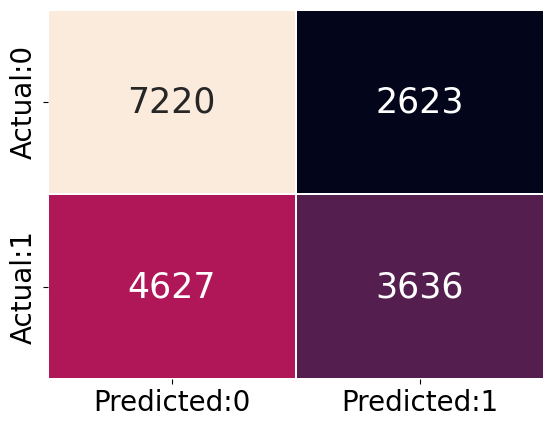

In [37]:
cm = confusion_matrix(y_test, y_pred)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

### Classification Report

In [38]:
acc_table = classification_report(y_test, y_pred)
print(acc_table)

              precision    recall  f1-score   support

           0       0.61      0.73      0.67      9843
           1       0.58      0.44      0.50      8263

    accuracy                           0.60     18106
   macro avg       0.60      0.59      0.58     18106
weighted avg       0.60      0.60      0.59     18106



In [39]:
kappa = cohen_kappa_score(y_test, y_pred)
print('kappa value:',kappa)

kappa value: 0.176995345766783


**Observations:** 
1. From the above output, we can infer that the **recall of the positive class** is known as **sensitivity** and the **recall of the negative class** is **specificity**.
2. **Support** is the **number of observations in the corresponding class**.
3. The **macro average** in the output is obtained by **averaging the unweighted mean per label** and the **weighted average** is given by **averaging the support-weighted mean per label**.
4. **Kappa score** is a **measure of inter-rater reliability**. For logistic regression, the actual and predicted values of the target variable are the raters.
5. As the kappa score for the full model (with cut-off probability 0.5) is **0.189**, we can say that there is **slight agreement between the actual and predicted values**.

### ROC curve

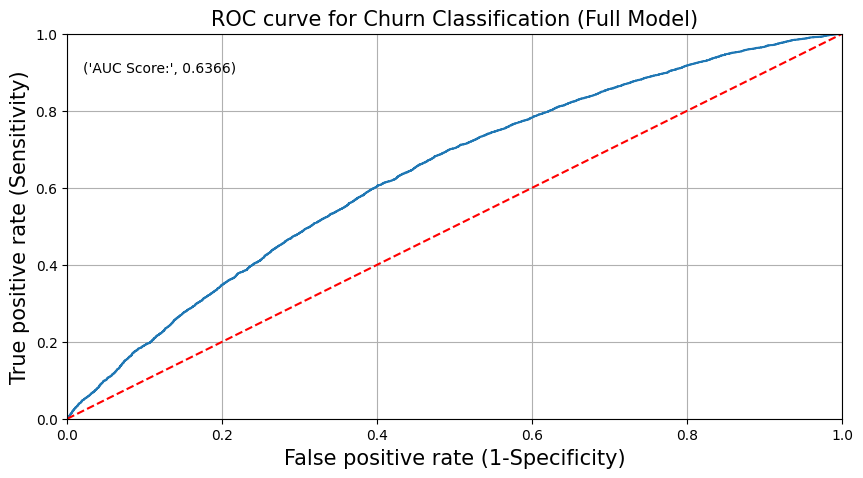

In [40]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve for Churn Classification (Full Model)', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(y_test, y_pred_prob),4)))
plt.grid(True)

**Observations:** 
1. ROC curve is plotted with the **true positive rate (tpr) on the y-axis** and **false positive rate (fpr) on the x-axis**. The area under this curve is used as a **measure of separability of the model**.
2. The **red dotted line** represents the ROC curve of a **purely random classifier**. A good classifier stays as far away from that line as possible (toward the top-left corner).
3. From the above plot, we can see that our classifier (logistic regression) is **near the dotted line**, with the **AUC score 0.644**.

In [41]:
cols = ['test_accuracy', 'train_accuracy', 'test_precision', 'train_precision','test_recall','train_recall', 'test_kappa', 'train_kappa', 'f1_score','roc_auc_score']
model_evaluation = pd.DataFrame(columns=cols)
model_evaluation.loc['Logit_FullModel'] = [accuracy_score(y_test,y_pred), accuracy_score(y_train,y_pred_train),
                                          precision_score(y_test,y_pred), precision_score(y_train,y_pred_train),
                                          recall_score(y_test,y_pred), recall_score(y_train,y_pred_train),
                                          cohen_kappa_score(y_test,y_pred), cohen_kappa_score(y_train,y_pred_train),
                                          f1_score(y_test,y_pred), roc_auc_score(y_test,y_pred_prob)]
model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
Logit_FullModel,0.59958,0.604664,0.580923,0.585135,0.440034,0.440811,0.176995,0.185339,0.500757,0.636576


### Identify the Best Cut-off Value - Youden's Index

In [42]:
youdens_table = pd.DataFrame({'TPR': tpr,
                             'FPR': fpr,
                             'Threshold': thresholds})
youdens_table['Difference'] = youdens_table.TPR - youdens_table.FPR
youdens_table = youdens_table.sort_values('Difference', ascending = False).reset_index(drop = True)
youdens_table.head()

,TPR,FPR,Threshold,Difference
0,0.681956,0.474449,0.434289,0.207507
1,0.680988,0.473839,0.434408,0.207148
2,0.680867,0.473738,0.434422,0.207129
3,0.682077,0.474957,0.434159,0.207120
4,0.682198,0.475160,0.434126,0.207038


**Observations:**
1. Youden's Index is the classification cut-off probability for which the (Sensitivity + Specificity - 1) is maximized.
2. Youden's Index = max(Sensitivity + Specificity - 1) = max(TPR + TNR - 1) = max(TPR - FPR)
3. As we can see that the **optimal cut-off probability is approximately 0.455**. Let us consider this cut-off to predict the target values, i.e., if `y_pred_prob` is less than 0.455, then consider it to be 0 else consider it to be 1.
4. Model evaluation metrics are calculated with the cut-off value obtained from youden's cut-off value. 

In [43]:
y_pred_train_youden = [ 0 if x < 0.455 else 1 for x in y_pred_prob_train]
y_pred_youden = [ 0 if x < 0.455 else 1 for x in y_pred_prob]

In [44]:
model_evaluation.loc['Logit_FullModel'] = [accuracy_score(y_test,y_pred_youden), accuracy_score(y_train,y_pred_train_youden),
                                          precision_score(y_test,y_pred_youden), precision_score(y_train,y_pred_train_youden),
                                          recall_score(y_test,y_pred_youden), recall_score(y_train,y_pred_train_youden),
                                          cohen_kappa_score(y_test,y_pred_youden), cohen_kappa_score(y_train,y_pred_train_youden),
                                          f1_score(y_test,y_pred_youden), roc_auc_score(y_test,y_pred_prob)]
model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
Logit_FullModel,0.601513,0.604402,0.558365,0.558812,0.60668,0.606656,0.20245,0.207675,0.581521,0.636576


<a id="decisionTree"></a>
## 16.3. Decision Tree model

In [45]:
xtrain_dt, xtest_dt, ytrain_dt, ytest_dt = train_test_split(X, df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_dt.shape)
print('ytrain: ', ytrain_dt.shape)
print('xtest: ', xtest_dt.shape)
print('ytest: ', ytest_dt.shape)

xtrain:  (72422, 20)
ytrain:  (72422,)
xtest:  (18106, 20)
ytest:  (18106,)


In [46]:
tstats,pvals = stats.ttest_ind(xtrain_dt, xtest_dt)
ref_df = pd.DataFrame(pvals,index=xtrain_dt.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [47]:
decisionTree = DecisionTreeClassifier()
decisionTree = decisionTree.fit(xtrain_dt, ytrain_dt)

In [48]:
ypred_proba_dt = decisionTree.predict(xtest_dt)

In [49]:
ypred_dt = [0 if i < 0.5 else 1 for i in ypred_proba_dt]
ypred_dt[:10]

[0, 0, 0, 0, 1, 0, 1, 0, 1, 1]

In [50]:
ypred_proba_dt_train = decisionTree.predict(xtrain_dt)
ypred_dt_train = [0 if i < 0.5 else 1 for i in ypred_proba_dt_train]

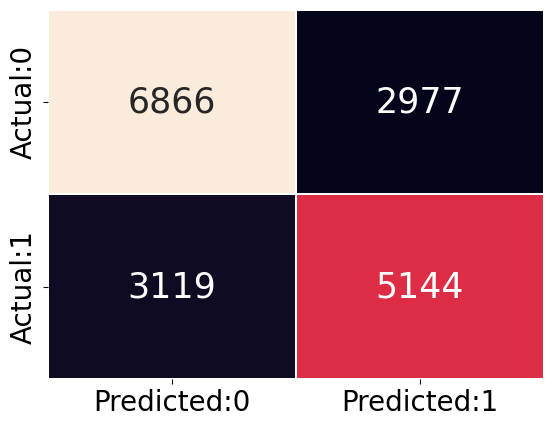

In [51]:
cm = confusion_matrix(ytest_dt, ypred_dt)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [52]:
print(classification_report(ytest_dt, ypred_dt))

              precision    recall  f1-score   support

           0       0.69      0.70      0.69      9843
           1       0.63      0.62      0.63      8263

    accuracy                           0.66     18106
   macro avg       0.66      0.66      0.66     18106
weighted avg       0.66      0.66      0.66     18106



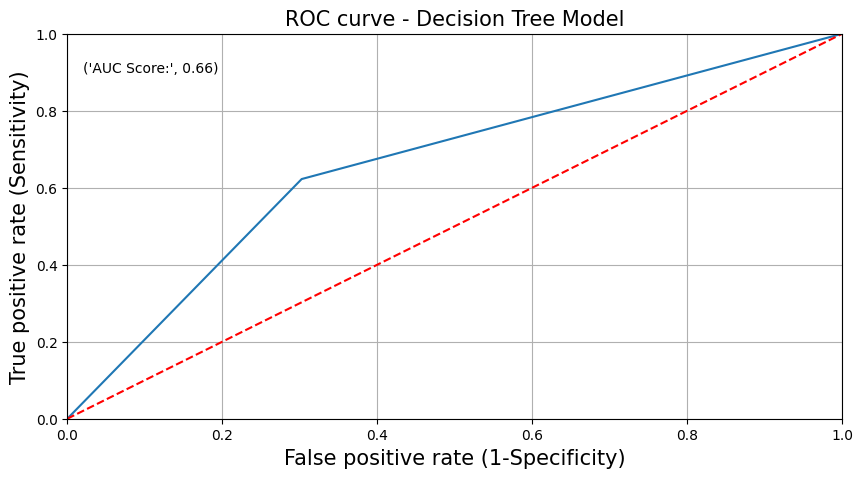

In [53]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_dt, ypred_proba_dt)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - Decision Tree Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_dt, ypred_proba_dt),4)))
plt.grid(True)

In [54]:
model_evaluation.loc['DecisionTree'] = [accuracy_score(ytest_dt, ypred_dt), accuracy_score(ytrain_dt, ypred_dt_train),
                                          precision_score(ytest_dt, ypred_dt), precision_score(ytrain_dt, ypred_dt_train),
                                          recall_score(ytest_dt, ypred_dt), recall_score(ytrain_dt, ypred_dt_train),
                                          cohen_kappa_score(ytest_dt, ypred_dt), cohen_kappa_score(ytrain_dt, ypred_dt_train),
                                          f1_score(ytest_dt, ypred_dt), roc_auc_score(ytest_dt, ypred_proba_dt)]
model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
Logit_FullModel,0.601513,0.604402,0.558365,0.558812,0.606680,0.606656,0.202450,0.207675,0.581521,0.636576
DecisionTree,0.663316,1.000000,0.633420,1.000000,0.622534,1.000000,0.320528,1.000000,0.627930,0.660043


<a id="xgboost"></a>
## 16.4. XG Boost Model

In [55]:
xtrain_xg, xtest_xg, ytrain_xg, ytest_xg = train_test_split(X, df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_xg.shape)
print('ytrain: ', ytrain_xg.shape)
print('xtest: ', xtest_xg.shape)
print('ytest: ', ytest_xg.shape)

xtrain:  (72422, 20)
ytrain:  (72422,)
xtest:  (18106, 20)
ytest:  (18106,)


In [56]:
tstats,pvals = stats.ttest_ind(xtrain_xg, xtest_xg)
ref_df = pd.DataFrame(pvals,index=xtrain_xg.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [57]:
xgBoost = XGBClassifier()
xbBoost = xgBoost.fit(xtrain_xg, ytrain_xg)

In [58]:
ypred_proba_xg = xgBoost.predict(xtest_xg)

In [59]:
ypred_xg = [0 if i < 0.5 else 1 for i in ypred_proba_xg]
ypred_xg[:10]

[0, 0, 0, 1, 1, 0, 1, 0, 1, 1]

In [60]:
ypred_proba_xg_train = xgBoost.predict(xtrain_xg)
ypred_xg_train = [0 if i < 0.5 else 1 for i in ypred_proba_xg_train]

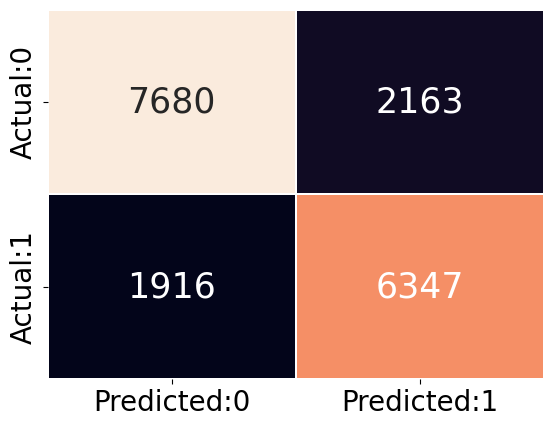

In [61]:
cm = confusion_matrix(ytest_xg, ypred_xg)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [62]:
print(classification_report(ytest_xg, ypred_xg))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      9843
           1       0.75      0.77      0.76      8263

    accuracy                           0.77     18106
   macro avg       0.77      0.77      0.77     18106
weighted avg       0.78      0.77      0.77     18106



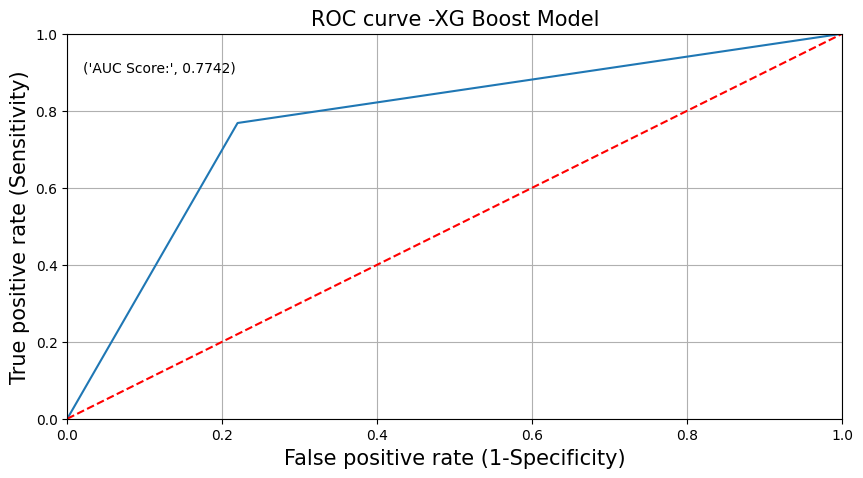

In [63]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_xg, ypred_proba_xg)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve -XG Boost Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_xg, ypred_proba_xg),4)))
plt.grid(True)

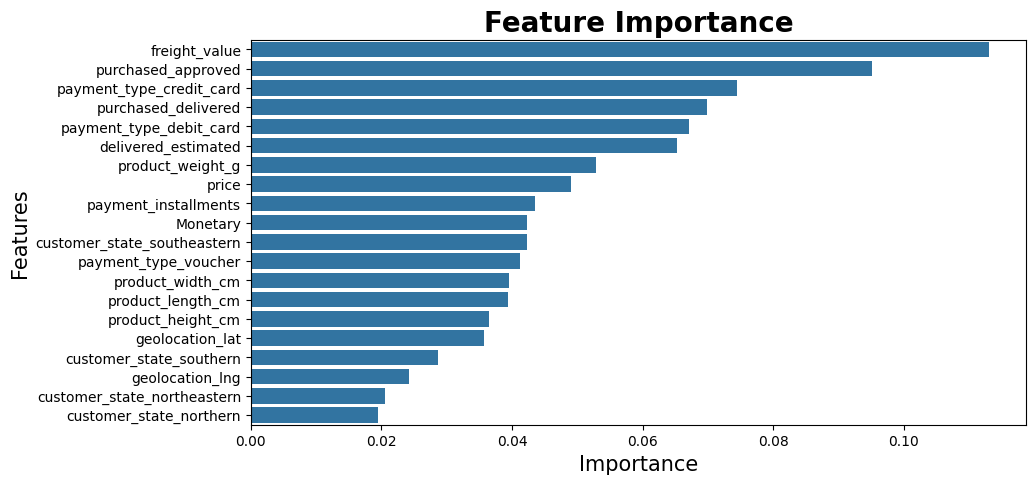

In [64]:
plt.figure(figsize=(10, 5))
important_features = pd.DataFrame({'Features': xtrain_xg.columns, 
                                   'Importance': xbBoost.feature_importances_})
important_features = important_features.sort_values('Importance', ascending = False)
sns.barplot(x = 'Importance', y = 'Features', data = important_features)
plt.title('Feature Importance',color='black',fontsize=20,fontweight='bold')
plt.xlabel('Importance',color='black',fontsize=15)
plt.ylabel('Features',color='black',fontsize=15)
plt.show()

In [65]:
model_evaluation.loc['XGBoost'] = [accuracy_score(ytest_xg, ypred_xg), accuracy_score(ytrain_xg, ypred_xg_train),
                                          precision_score(ytest_xg, ypred_xg), precision_score(ytrain_xg, ypred_xg_train),
                                          recall_score(ytest_xg, ypred_xg), recall_score(ytrain_xg, ypred_xg_train),
                                          cohen_kappa_score(ytest_xg, ypred_xg), cohen_kappa_score(ytrain_xg, ypred_xg_train),
                                          f1_score(ytest_xg, ypred_xg), roc_auc_score(ytest_xg, ypred_proba_xg)]
model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
Logit_FullModel,0.601513,0.604402,0.558365,0.558812,0.606680,0.606656,0.202450,0.207675,0.581521,0.636576
DecisionTree,0.663316,1.000000,0.633420,1.000000,0.622534,1.000000,0.320528,1.000000,0.627930,0.660043
XGBoost,0.774716,0.833034,0.745828,0.805554,0.768123,0.832877,0.547060,0.664125,0.756812,0.774186


<a id="randomForest"></a>
## 16.5. Random Forest Classifier

In [66]:
xtrain_random, xtest_random, ytrain_random, ytest_random = train_test_split(X, df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_random.shape)
print('ytrain: ', ytrain_random.shape)
print('xtest: ', xtest_random.shape)
print('ytest: ', ytest_random.shape)

xtrain:  (72422, 20)
ytrain:  (72422,)
xtest:  (18106, 20)
ytest:  (18106,)


In [67]:
tstats,pvals = stats.ttest_ind(xtrain_random, xtest_random)
ref_df = pd.DataFrame(pvals,index=xtrain_random.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [68]:
rand = RandomForestClassifier()
rand_model = rand.fit(xtrain_random,ytrain_random)

In [69]:
ypred_proba_random = rand_model.predict(xtest_random)

In [70]:
ypred_random = [0 if i < 0.5 else 1 for i in ypred_proba_random]
ypred_random[:10]

[0, 0, 0, 1, 1, 0, 1, 0, 1, 1]

In [71]:
ypred_proba_random_train = rand_model.predict(xtrain_random)
ypred_random_train = [0 if i < 0.5 else 1 for i in ypred_proba_random_train]

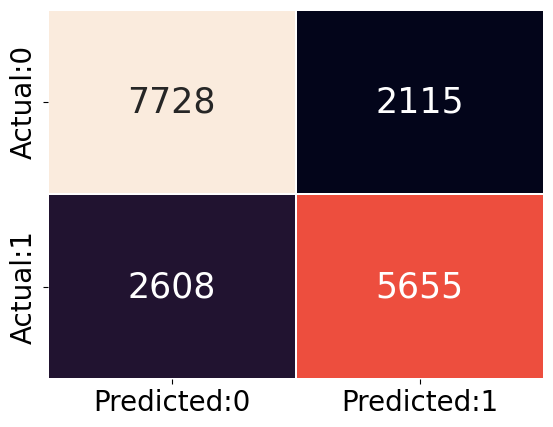

In [72]:
cm = confusion_matrix(ytest_random, ypred_random)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [73]:
print(classification_report(ytest_random, ypred_random))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77      9843
           1       0.73      0.68      0.71      8263

    accuracy                           0.74     18106
   macro avg       0.74      0.73      0.74     18106
weighted avg       0.74      0.74      0.74     18106



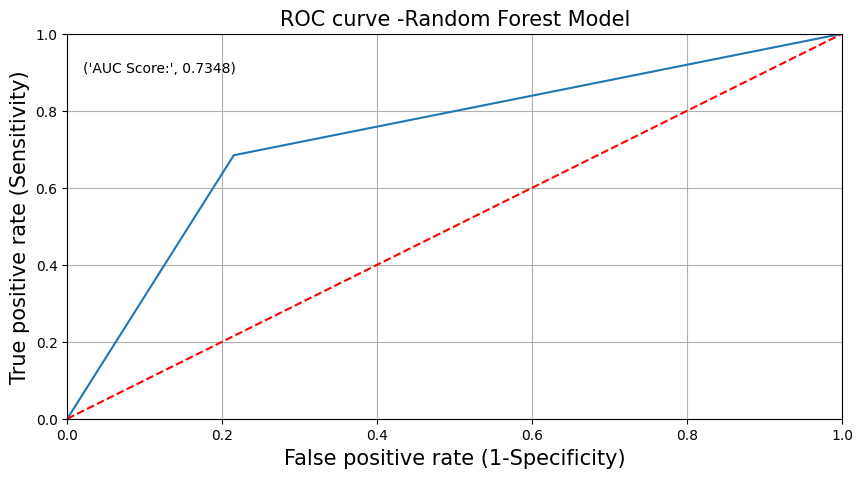

In [74]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_random, ypred_proba_random)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve -Random Forest Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_random, ypred_proba_random),4)))
plt.grid(True)

In [75]:
model_evaluation.loc['RandomForest Classifier'] = [accuracy_score(ytest_random, ypred_random), accuracy_score(ytrain_random, ypred_random_train),
                                          precision_score(ytest_random, ypred_random), precision_score(ytrain_random, ypred_random_train),
                                          recall_score(ytest_random, ypred_random), recall_score(ytrain_random, ypred_random_train),
                                          cohen_kappa_score(ytest_random, ypred_random), cohen_kappa_score(ytrain_random, ypred_random_train),
                                          f1_score(ytest_random, ypred_random), roc_auc_score(ytest_random, ypred_proba_random)]
model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
Logit_FullModel,0.601513,0.604402,0.558365,0.558812,0.606680,0.606656,0.202450,0.207675,0.581521,0.636576
DecisionTree,0.663316,1.000000,0.633420,1.000000,0.622534,1.000000,0.320528,1.000000,0.627930,0.660043
XGBoost,0.774716,0.833034,0.745828,0.805554,0.768123,0.832877,0.547060,0.664125,0.756812,0.774186
RandomForest Classifier,0.739147,1.000000,0.727799,1.000000,0.684376,1.000000,0.471762,1.000000,0.705420,0.734751


<a id="knn2"></a>
## 16.6. KNN 2 Clusters Model

In [76]:
xtrain_kn, xtest_kn, ytrain_kn, ytest_kn = train_test_split(X, df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_kn.shape)
print('ytrain: ', ytrain_kn.shape)
print('xtest: ', xtest_kn.shape)
print('ytest: ', ytest_kn.shape)

xtrain:  (72422, 20)
ytrain:  (72422,)
xtest:  (18106, 20)
ytest:  (18106,)


In [77]:
tstats,pvals = stats.ttest_ind(xtrain_kn, xtest_kn)
ref_df = pd.DataFrame(pvals,index=xtrain_kn.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [78]:
knn = KNeighborsClassifier(n_neighbors=2)
knn_model = knn.fit(xtrain_kn,ytrain_kn)

In [79]:
ypred_proba_knn = knn_model.predict(xtest_kn)
ypred_knn = [0 if i < 0.5 else 1 for i in ypred_proba_knn]
ypred_knn[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 1, 1]

In [80]:
ypred_proba_knn_train = knn_model.predict(xtrain_kn)
ypred_knn_train = [0 if i < 0.5 else 1 for i in ypred_proba_knn_train]

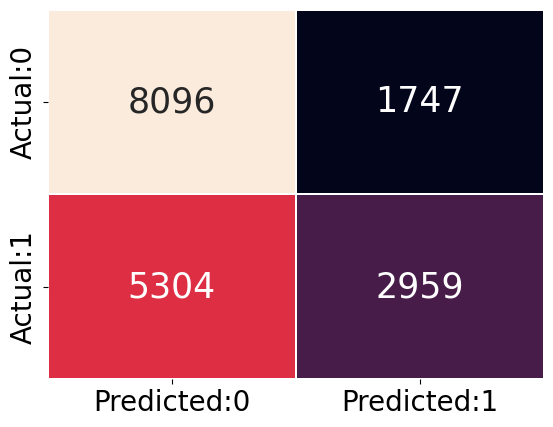

In [81]:
cm = confusion_matrix(ytest_kn, ypred_knn)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [82]:
print(classification_report(ytest_kn, ypred_knn))

              precision    recall  f1-score   support

           0       0.60      0.82      0.70      9843
           1       0.63      0.36      0.46      8263

    accuracy                           0.61     18106
   macro avg       0.62      0.59      0.58     18106
weighted avg       0.62      0.61      0.59     18106



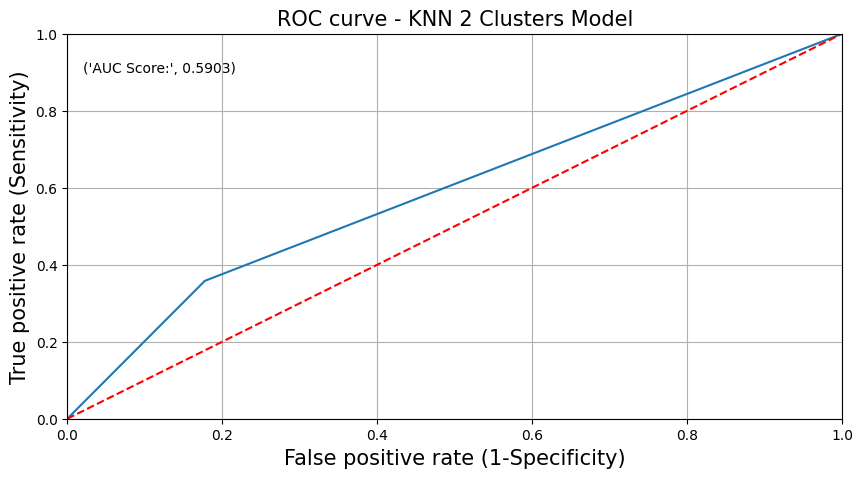

In [83]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_kn, ypred_proba_knn)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - KNN 2 Clusters Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_kn, ypred_proba_knn),4)))
plt.grid(True)

In [84]:
model_evaluation.loc['KNN 2 Cluster'] = [accuracy_score(ytest_kn, ypred_knn), accuracy_score(ytrain_kn, ypred_knn_train),
                                          precision_score(ytest_kn, ypred_knn), precision_score(ytrain_kn, ypred_knn_train),
                                          recall_score(ytest_kn, ypred_knn), recall_score(ytrain_kn, ypred_knn_train),
                                          cohen_kappa_score(ytest_kn, ypred_knn), cohen_kappa_score(ytrain_kn, ypred_knn_train),
                                          f1_score(ytest_kn, ypred_knn), roc_auc_score(ytest_kn, ypred_proba_knn)]
model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
Logit_FullModel,0.601513,0.604402,0.558365,0.558812,0.606680,0.606656,0.202450,0.207675,0.581521,0.636576
DecisionTree,0.663316,1.000000,0.633420,1.000000,0.622534,1.000000,0.320528,1.000000,0.627930,0.660043
XGBoost,0.774716,0.833034,0.745828,0.805554,0.768123,0.832877,0.547060,0.664125,0.756812,0.774186
RandomForest Classifier,0.739147,1.000000,0.727799,1.000000,0.684376,1.000000,0.471762,1.000000,0.705420,0.734751
KNN 2 Cluster,0.610571,0.813040,0.628772,1.000000,0.358102,0.587748,0.187079,0.609110,0.456319,0.590308


<a id="knn3"></a>
## 16.7. KNN 3 Clusters Model

In [85]:
xtrain_knn, xtest_knn, ytrain_knn, ytest_knn = train_test_split(X, df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_knn.shape)
print('ytrain: ', ytrain_knn.shape)
print('xtest: ', xtest_knn.shape)
print('ytest: ', ytest_knn.shape)

xtrain:  (72422, 20)
ytrain:  (72422,)
xtest:  (18106, 20)
ytest:  (18106,)


In [86]:
tstats,pvals = stats.ttest_ind(xtrain_knn, xtest_knn)
ref_df = pd.DataFrame(pvals,index=xtrain_knn.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [87]:
knn = KNeighborsClassifier(n_neighbors=3)
knn_model = knn.fit(xtrain_knn,ytrain_knn)

In [88]:
ypred_proba_knn = knn_model.predict(xtest_knn)
ypred_knn = [0 if i < 0.5 else 1 for i in ypred_proba_knn]
ypred_knn[:10]

[1, 0, 0, 0, 1, 0, 0, 0, 1, 1]

In [89]:
ypred_proba_knn_train = knn_model.predict(xtrain_knn)
ypred_knn_train = [0 if i < 0.5 else 1 for i in ypred_proba_knn_train]

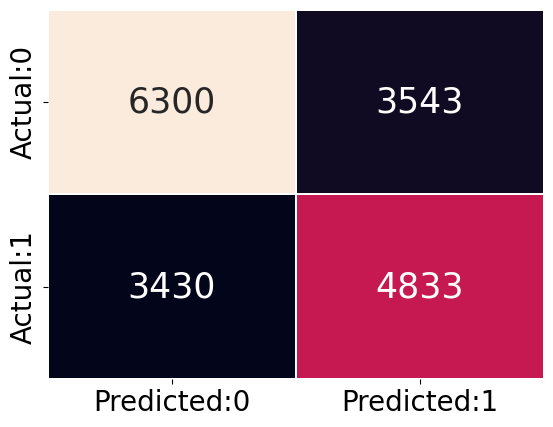

In [90]:
cm = confusion_matrix(ytest_knn, ypred_knn)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [91]:
print(classification_report(ytest_knn, ypred_knn))

              precision    recall  f1-score   support

           0       0.65      0.64      0.64      9843
           1       0.58      0.58      0.58      8263

    accuracy                           0.61     18106
   macro avg       0.61      0.61      0.61     18106
weighted avg       0.62      0.61      0.62     18106



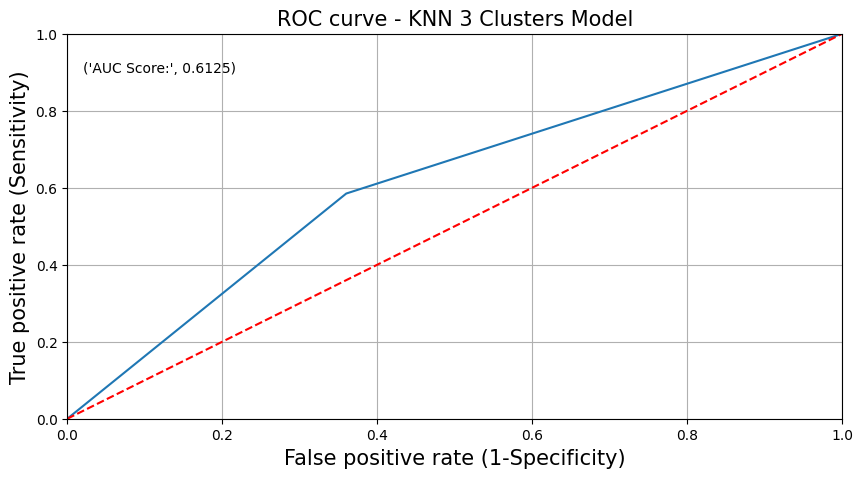

In [92]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_knn, ypred_proba_knn)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - KNN 3 Clusters Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_knn, ypred_proba_knn),4)))
plt.grid(True)

In [93]:
model_evaluation.loc['KNN 3 Cluster'] = [accuracy_score(ytest_knn, ypred_knn), accuracy_score(ytrain_knn, ypred_knn_train),
                                          precision_score(ytest_knn, ypred_knn), precision_score(ytrain_knn, ypred_knn_train),
                                          recall_score(ytest_knn, ypred_knn), recall_score(ytrain_knn, ypred_knn_train),
                                          cohen_kappa_score(ytest_knn, ypred_knn), cohen_kappa_score(ytrain_knn, ypred_knn_train),
                                          f1_score(ytest_knn, ypred_knn), roc_auc_score(ytest_knn, ypred_proba_knn)]
model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
Logit_FullModel,0.601513,0.604402,0.558365,0.558812,0.606680,0.606656,0.202450,0.207675,0.581521,0.636576
DecisionTree,0.663316,1.000000,0.633420,1.000000,0.622534,1.000000,0.320528,1.000000,0.627930,0.660043
XGBoost,0.774716,0.833034,0.745828,0.805554,0.768123,0.832877,0.547060,0.664125,0.756812,0.774186
RandomForest Classifier,0.739147,1.000000,0.727799,1.000000,0.684376,1.000000,0.471762,1.000000,0.705420,0.734751
KNN 2 Cluster,0.610571,0.813040,0.628772,1.000000,0.358102,0.587748,0.187079,0.609110,0.456319,0.590308
KNN 3 Cluster,0.614879,0.809312,0.577006,0.788499,0.584897,0.791956,0.224699,0.615442,0.580924,0.612473


<a id="logistic"></a>
## 16.8. Logistic Regression

In [94]:
xtrain_log, xtest_log, ytrain_log, ytest_log = train_test_split(X, df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_log.shape)
print('ytrain: ', ytrain_log.shape)
print('xtest: ', xtest_log.shape)
print('ytest: ', ytest_log.shape)

xtrain:  (72422, 20)
ytrain:  (72422,)
xtest:  (18106, 20)
ytest:  (18106,)


In [95]:
tstats,pvals = stats.ttest_ind(xtrain_log, xtest_log)
ref_df = pd.DataFrame(pvals,index=xtrain_log.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [96]:
lr = LogisticRegression()
lr_model = lr.fit(xtrain_log,ytrain_log)

In [97]:
ypred_proba_log = lr_model.predict(xtest_log)
ypred_log = [0 if i < 0.5 else 1 for i in ypred_proba_log]
ypred_log[:10]

[0, 0, 0, 1, 0, 0, 1, 0, 1, 1]

In [98]:
ypred_proba_log_train = lr_model.predict(xtrain_log)
ypred_log_train = [0 if i < 0.5 else 1 for i in ypred_proba_log_train]

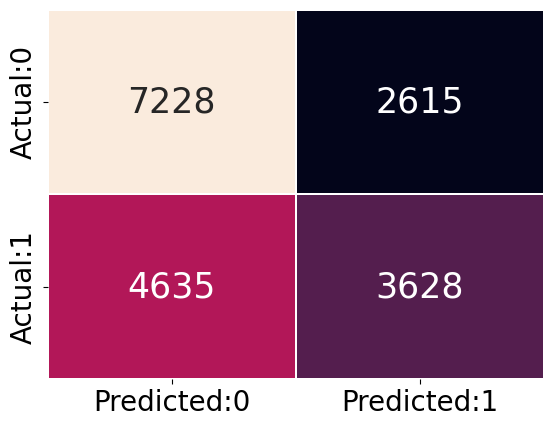

In [99]:
cm = confusion_matrix(ytest_log, ypred_log)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [100]:
print(classification_report(ytest_log, ypred_log))

              precision    recall  f1-score   support

           0       0.61      0.73      0.67      9843
           1       0.58      0.44      0.50      8263

    accuracy                           0.60     18106
   macro avg       0.60      0.59      0.58     18106
weighted avg       0.60      0.60      0.59     18106



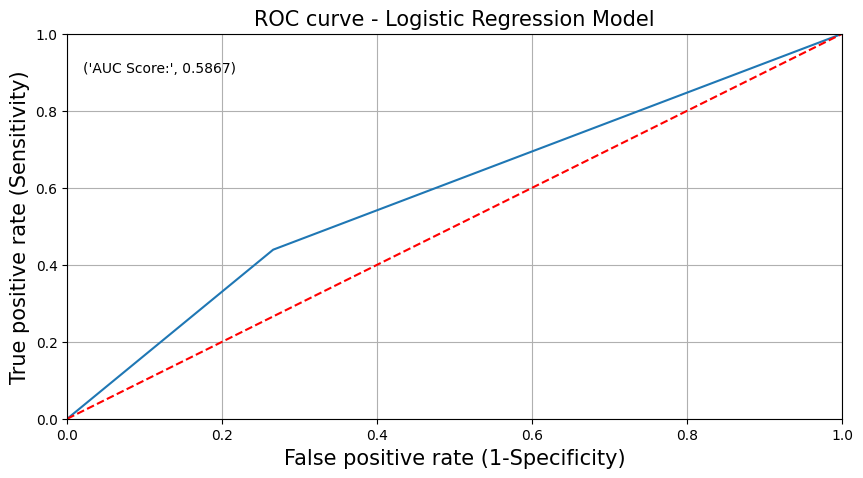

In [101]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_log, ypred_proba_log)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - Logistic Regression Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_log, ypred_proba_log),4)))
plt.grid(True)

In [102]:
model_evaluation.loc['Logistic'] = [accuracy_score(ytest_log, ypred_log), accuracy_score(ytrain_log, ypred_log_train),
                                          precision_score(ytest_log, ypred_log), precision_score(ytrain_log, ypred_log_train),
                                          recall_score(ytest_log, ypred_log), recall_score(ytrain_log, ypred_log_train),
                                          cohen_kappa_score(ytest_log, ypred_log), cohen_kappa_score(ytrain_log, ypred_log_train),
                                          f1_score(ytest_log, ypred_log), roc_auc_score(ytest_log, ypred_proba_log)]
model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
Logit_FullModel,0.601513,0.604402,0.558365,0.558812,0.606680,0.606656,0.202450,0.207675,0.581521,0.636576
DecisionTree,0.663316,1.000000,0.633420,1.000000,0.622534,1.000000,0.320528,1.000000,0.627930,0.660043
XGBoost,0.774716,0.833034,0.745828,0.805554,0.768123,0.832877,0.547060,0.664125,0.756812,0.774186
RandomForest Classifier,0.739147,1.000000,0.727799,1.000000,0.684376,1.000000,0.471762,1.000000,0.705420,0.734751
KNN 2 Cluster,0.610571,0.813040,0.628772,1.000000,0.358102,0.587748,0.187079,0.609110,0.456319,0.590308
KNN 3 Cluster,0.614879,0.809312,0.577006,0.788499,0.584897,0.791956,0.224699,0.615442,0.580924,0.612473
Logistic,0.599580,0.604678,0.581131,0.585304,0.439066,0.440172,0.176865,0.185275,0.500207,0.586697


<a id="naive"></a>
## 16.9. Navie Bayes

In [103]:
xtrain_nav, xtest_nav, ytrain_nav, ytest_nav = train_test_split(X, df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_nav.shape)
print('ytrain: ', ytrain_nav.shape)
print('xtest: ', xtest_nav.shape)
print('ytest: ', ytest_nav.shape)

xtrain:  (72422, 20)
ytrain:  (72422,)
xtest:  (18106, 20)
ytest:  (18106,)


In [104]:
tstats,pvals = stats.ttest_ind(xtrain_nav, xtest_nav)
ref_df = pd.DataFrame(pvals,index=xtrain_nav.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [105]:
nb = GaussianNB()
nb_model = lr.fit(xtrain_nav,ytrain_nav)

In [106]:
ypred_proba_nav = nb_model.predict(xtest_nav)
ypred_nav = [0 if i < 0.5 else 1 for i in ypred_proba_nav]
ypred_nav[:10]

[0, 0, 0, 1, 0, 0, 1, 0, 1, 1]

In [107]:
ypred_proba_nav_train = nb_model.predict(xtrain_nav)
ypred_nav_train = [0 if i < 0.5 else 1 for i in ypred_proba_nav_train]

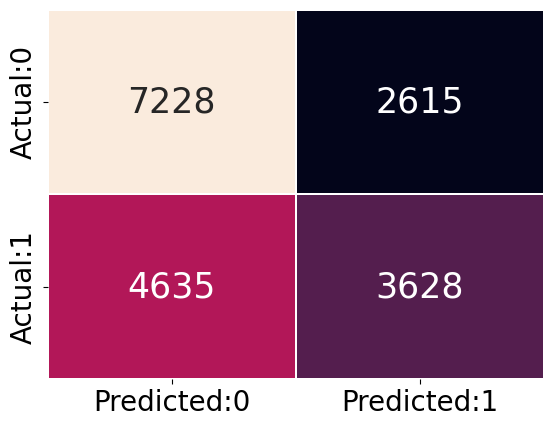

In [108]:
cm = confusion_matrix(ytest_nav, ypred_nav)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [109]:
print(classification_report(ytest_nav, ypred_nav))

              precision    recall  f1-score   support

           0       0.61      0.73      0.67      9843
           1       0.58      0.44      0.50      8263

    accuracy                           0.60     18106
   macro avg       0.60      0.59      0.58     18106
weighted avg       0.60      0.60      0.59     18106



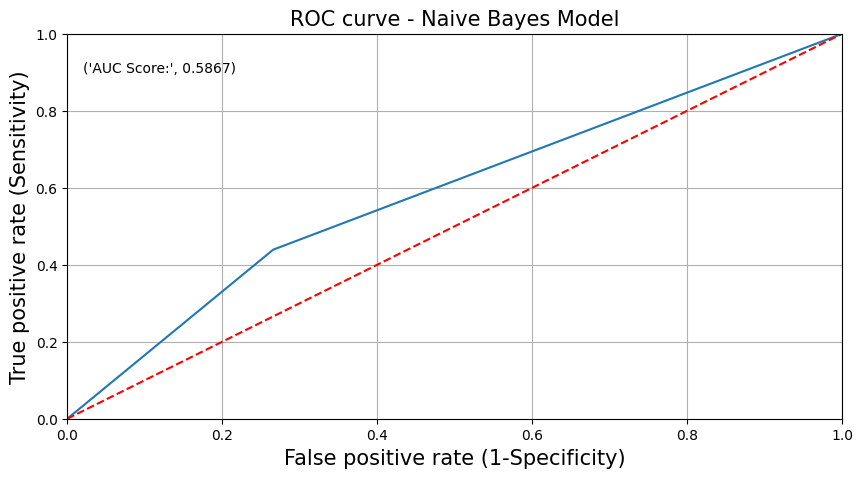

In [110]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_nav, ypred_proba_nav)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - Naive Bayes Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_nav, ypred_proba_nav),4)))
plt.grid(True)

In [111]:
model_evaluation.loc['GaussianNB'] = [accuracy_score(ytest_nav, ypred_nav), accuracy_score(ytrain_nav, ypred_nav_train),
                                          precision_score(ytest_nav, ypred_nav), precision_score(ytrain_nav, ypred_nav_train),
                                          recall_score(ytest_nav, ypred_nav), recall_score(ytrain_nav, ypred_nav_train),
                                          cohen_kappa_score(ytest_nav, ypred_nav), cohen_kappa_score(ytrain_nav, ypred_nav_train),
                                          f1_score(ytest_nav, ypred_nav), roc_auc_score(ytest_nav, ypred_proba_nav)]

model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
Logit_FullModel,0.601513,0.604402,0.558365,0.558812,0.606680,0.606656,0.202450,0.207675,0.581521,0.636576
DecisionTree,0.663316,1.000000,0.633420,1.000000,0.622534,1.000000,0.320528,1.000000,0.627930,0.660043
XGBoost,0.774716,0.833034,0.745828,0.805554,0.768123,0.832877,0.547060,0.664125,0.756812,0.774186
RandomForest Classifier,0.739147,1.000000,0.727799,1.000000,0.684376,1.000000,0.471762,1.000000,0.705420,0.734751
KNN 2 Cluster,0.610571,0.813040,0.628772,1.000000,0.358102,0.587748,0.187079,0.609110,0.456319,0.590308
KNN 3 Cluster,0.614879,0.809312,0.577006,0.788499,0.584897,0.791956,0.224699,0.615442,0.580924,0.612473
Logistic,0.599580,0.604678,0.581131,0.585304,0.439066,0.440172,0.176865,0.185275,0.500207,0.586697
GaussianNB,0.599580,0.604678,0.581131,0.585304,0.439066,0.440172,0.176865,0.185275,0.500207,0.586697


<a id="rfe"></a>
# 17. Recursive Feature Elimination for top 4 models 

In [112]:
model_evaluation.sort_values(by='test_recall',ascending=False)

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
XGBoost,0.774716,0.833034,0.745828,0.805554,0.768123,0.832877,0.547060,0.664125,0.756812,0.774186
RandomForest Classifier,0.739147,1.000000,0.727799,1.000000,0.684376,1.000000,0.471762,1.000000,0.705420,0.734751
DecisionTree,0.663316,1.000000,0.633420,1.000000,0.622534,1.000000,0.320528,1.000000,0.627930,0.660043
Logit_FullModel,0.601513,0.604402,0.558365,0.558812,0.606680,0.606656,0.202450,0.207675,0.581521,0.636576
KNN 3 Cluster,0.614879,0.809312,0.577006,0.788499,0.584897,0.791956,0.224699,0.615442,0.580924,0.612473
Logistic,0.599580,0.604678,0.581131,0.585304,0.439066,0.440172,0.176865,0.185275,0.500207,0.586697
GaussianNB,0.599580,0.604678,0.581131,0.585304,0.439066,0.440172,0.176865,0.185275,0.500207,0.586697
KNN 2 Cluster,0.610571,0.813040,0.628772,1.000000,0.358102,0.587748,0.187079,0.609110,0.456319,0.590308


<a id="rfexg"></a>
## 17.1. XGBoost Model - RFE

In [113]:
X_train_rfe = X_train.iloc[:,1:]
X_test_rfe = X_test.iloc[:,1:]
xg =  XGBClassifier()
xgb_model = RFE(estimator = xg, n_features_to_select = 10)
rfe_model = xgb_model.fit(X_train_rfe, y_train)
feat_index = pd.Series(data = rfe_model.ranking_, index = X_train_rfe.columns)
signi_feat_rfe_xg = feat_index[feat_index==1].index
print(signi_feat_rfe_xg)

Index(['purchased_approved', 'delivered_estimated', 'purchased_delivered',
       'price', 'freight_value', 'product_weight_g', 'payment_installments',
       'Monetary', 'payment_type_credit_card', 'payment_type_debit_card'],
      dtype='object')


In [114]:
xtrain_xg, xtest_xg, ytrain_xg, ytest_xg = train_test_split(X[signi_feat_rfe_xg], df_target, random_state = 500, test_size = 0.2)
print('xtrain: ', xtrain_xg.shape)
print('ytrain: ', ytrain_xg.shape)
print('xtest: ', xtest_xg.shape)
print('ytest: ', ytest_xg.shape)

xtrain:  (72422, 10)
ytrain:  (72422,)
xtest:  (18106, 10)
ytest:  (18106,)


In [115]:
tstats,pvals = stats.ttest_ind(xtrain_nav, xtest_nav)
ref_df = pd.DataFrame(pvals,index=xtrain_nav.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [116]:
gBoost = XGBClassifier()
xbBoost = xgBoost.fit(xtrain_xg, ytrain_xg)

In [117]:
ypred_proba_xg = xgBoost.predict(xtest_xg)
ypred_xg = [0 if i < 0.5 else 1 for i in ypred_proba_xg]
ypred_xg[:10]

[0, 0, 0, 1, 0, 1, 1, 0, 1, 1]

In [118]:
ypred_proba_xg_train = xgBoost.predict(xtrain_xg)
ypred_xg_train = [0 if i < 0.5 else 1 for i in ypred_proba_xg_train]

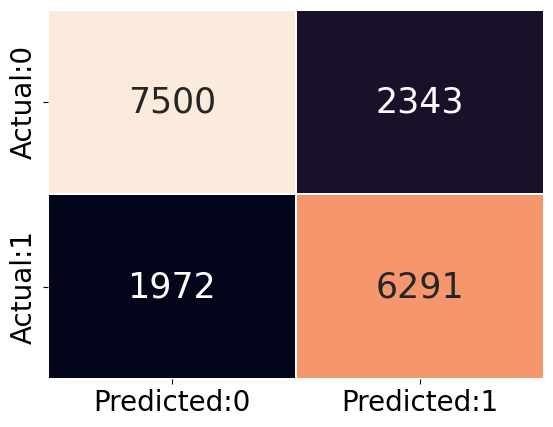

In [119]:
cm = confusion_matrix(ytest_xg, ypred_xg)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [120]:
print(classification_report(ytest_xg, ypred_xg))

              precision    recall  f1-score   support

           0       0.79      0.76      0.78      9843
           1       0.73      0.76      0.74      8263

    accuracy                           0.76     18106
   macro avg       0.76      0.76      0.76     18106
weighted avg       0.76      0.76      0.76     18106



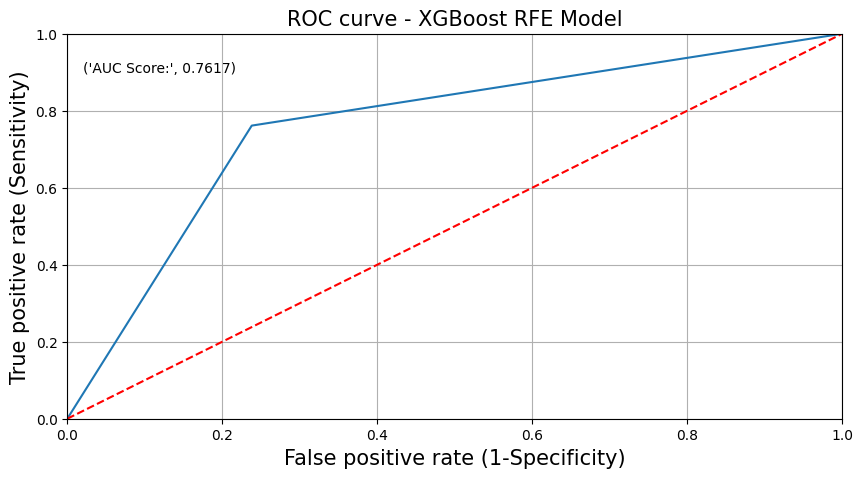

In [121]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_xg, ypred_proba_xg)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - XGBoost RFE Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_xg, ypred_proba_xg),4)))
plt.grid(True)

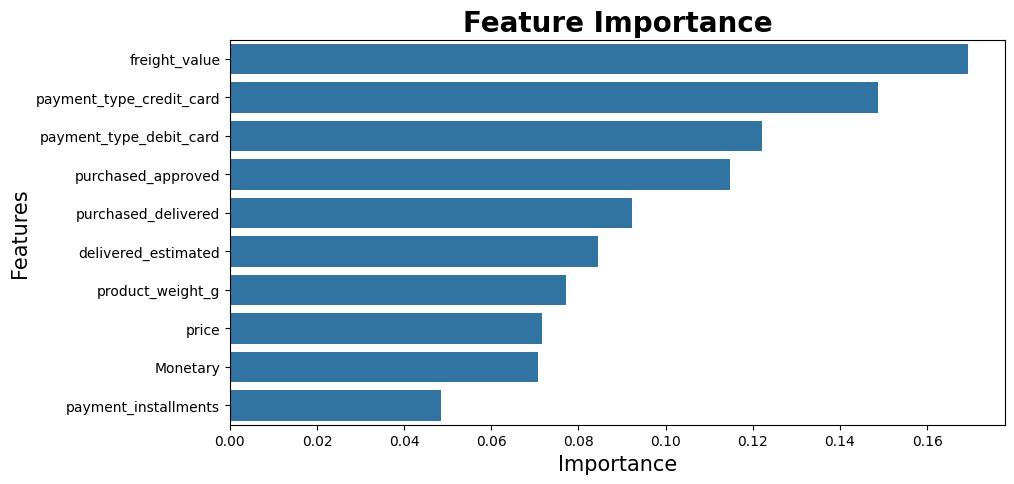

In [122]:
plt.figure(figsize=(10, 5))
important_features = pd.DataFrame({'Features': xtrain_xg.columns, 
                                   'Importance': xbBoost.feature_importances_})
important_features = important_features.sort_values('Importance', ascending = False)
sns.barplot(x = 'Importance', y = 'Features', data = important_features)
plt.title('Feature Importance',color='black',fontsize=20,fontweight='bold')
plt.xlabel('Importance',color='black',fontsize=15)
plt.ylabel('Features',color='black',fontsize=15)
plt.show()

In [123]:
cols = ['test_accuracy', 'train_accuracy', 'test_precision', 'train_precision','test_recall','train_recall', 'test_kappa', 'train_kappa', 'f1_score','roc_auc_score']
RFE_model_evaluation = pd.DataFrame(columns=cols)
RFE_model_evaluation.loc['XGBoost RFE'] = [accuracy_score(ytest_xg, ypred_xg), accuracy_score(ytrain_xg, ypred_xg_train),
                                          precision_score(ytest_xg, ypred_xg), precision_score(ytrain_xg, ypred_xg_train),
                                          recall_score(ytest_xg, ypred_xg), recall_score(ytrain_xg, ypred_xg_train),
                                          cohen_kappa_score(ytest_xg, ypred_xg), cohen_kappa_score(ytrain_xg, ypred_xg_train),
                                          f1_score(ytest_xg, ypred_xg), roc_auc_score(ytest_xg, ypred_proba_xg)]
RFE_model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
XGBoost RFE,0.761681,0.811977,0.728631,0.779617,0.761346,0.8161,0.52143,0.622179,0.744629,0.761654


<a id="rferf"></a>
## 17.2. Random Forest Classifier - RFE

In [124]:
X_train_rfe = X_train.iloc[:,1:]
X_test_rfe = X_test.iloc[:,1:]
rand =  RandomForestClassifier()
rand_model = RFE(estimator = rand, n_features_to_select = 10)
rfe_model = rand_model.fit(X_train_rfe, y_train)
feat_index = pd.Series(data = rfe_model.ranking_, index = X_train_rfe.columns)
signi_feat_rfe_rf = feat_index[feat_index==1].index
print(signi_feat_rfe_rf)

Index(['purchased_approved', 'delivered_estimated', 'purchased_delivered',
       'price', 'freight_value', 'product_weight_g', 'product_width_cm',
       'geolocation_lat', 'geolocation_lng', 'Monetary'],
      dtype='object')


In [125]:
xtrain_random, xtest_random, ytrain_random, ytest_random = train_test_split(X[signi_feat_rfe_rf], df_target, random_state = 500, test_size = 0.2)
print('xtrain: ', xtrain_random.shape)
print('ytrain: ', ytrain_random.shape)
print('xtest: ', xtest_random.shape)
print('ytest: ', ytest_random.shape)

xtrain:  (72422, 10)
ytrain:  (72422,)
xtest:  (18106, 10)
ytest:  (18106,)


In [126]:
tstats,pvals = stats.ttest_ind(xtrain_nav, xtest_nav)
ref_df = pd.DataFrame(pvals,index=xtrain_nav.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [127]:
rand = RandomForestClassifier()
rand_model = rand.fit(xtrain_random,ytrain_random)

In [128]:
ypred_proba_random = rand_model.predict(xtest_random)
ypred_random = [0 if i < 0.5 else 1 for i in ypred_proba_random]
ypred_random[:10]

[0, 0, 0, 1, 1, 0, 1, 0, 1, 1]

In [129]:
ypred_proba_random_train = rand_model.predict(xtrain_random)
ypred_random_train = [0 if i < 0.5 else 1 for i in ypred_proba_random_train]

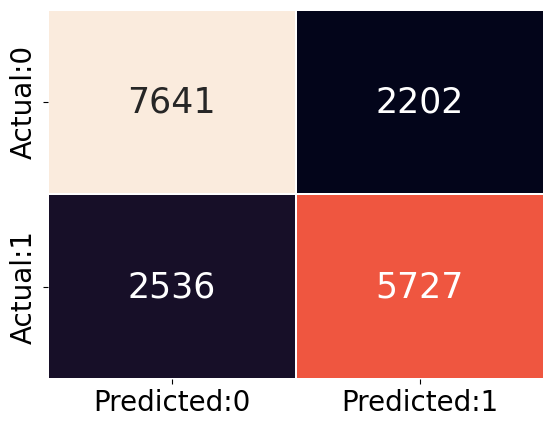

In [130]:
cm = confusion_matrix(ytest_random, ypred_random)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [131]:
print(classification_report(ytest_random, ypred_random))

              precision    recall  f1-score   support

           0       0.75      0.78      0.76      9843
           1       0.72      0.69      0.71      8263

    accuracy                           0.74     18106
   macro avg       0.74      0.73      0.74     18106
weighted avg       0.74      0.74      0.74     18106



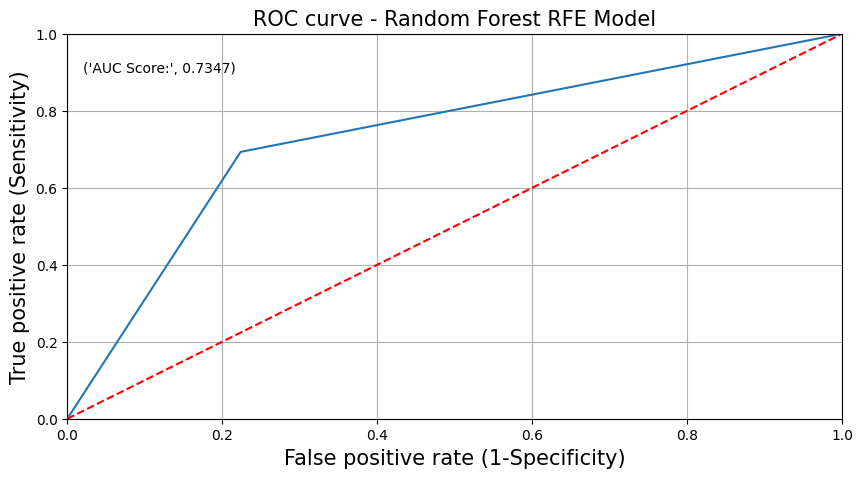

In [132]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_random, ypred_proba_random)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - Random Forest RFE Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_random, ypred_proba_random),4)))
plt.grid(True)

In [133]:
RFE_model_evaluation.loc['RandomForest Classifier'] = [accuracy_score(ytest_random, ypred_random), accuracy_score(ytrain_random, ypred_random_train),
                                          precision_score(ytest_random, ypred_random), precision_score(ytrain_random, ypred_random_train),
                                          recall_score(ytest_random, ypred_random), recall_score(ytrain_random, ypred_random_train),
                                          cohen_kappa_score(ytest_random, ypred_random), cohen_kappa_score(ytrain_random, ypred_random_train),
                                          f1_score(ytest_random, ypred_random), roc_auc_score(ytest_random, ypred_proba_random)]
RFE_model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
XGBoost RFE,0.761681,0.811977,0.728631,0.779617,0.761346,0.8161,0.521430,0.622179,0.744629,0.761654
RandomForest Classifier,0.738319,1.000000,0.722285,1.000000,0.693090,1.0000,0.470905,1.000000,0.707386,0.734689


<a id="rfedt"></a>
## 17.3. Decision Tree Classifier - RFE

In [134]:
X_train_rfe = X_train.iloc[:,1:]
X_test_rfe = X_test.iloc[:,1:]
dt =  DecisionTreeClassifier()
dt_model = RFE(estimator = dt, n_features_to_select = 10)
rfe_model = dt_model.fit(X_train_rfe, y_train)
feat_index = pd.Series(data = rfe_model.ranking_, index = X_train_rfe.columns)
signi_feat_rfe_dt = feat_index[feat_index==1].index
print(signi_feat_rfe_dt)

Index(['purchased_approved', 'delivered_estimated', 'purchased_delivered',
       'price', 'freight_value', 'product_weight_g', 'product_length_cm',
       'geolocation_lat', 'geolocation_lng', 'Monetary'],
      dtype='object')


In [135]:
xtrain_dt, xtest_dt, ytrain_dt, ytest_dt = train_test_split(X[signi_feat_rfe_dt], df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_dt.shape)
print('ytrain: ', ytrain_dt.shape)
print('xtest: ', xtest_dt.shape)
print('ytest: ', ytest_dt.shape)

xtrain:  (72422, 10)
ytrain:  (72422,)
xtest:  (18106, 10)
ytest:  (18106,)


In [136]:
tstats,pvals = stats.ttest_ind(xtrain_dt, xtest_dt)
ref_df = pd.DataFrame(pvals,index=xtrain_dt.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [137]:
decisionTree = DecisionTreeClassifier()
decisionTree = decisionTree.fit(xtrain_dt, ytrain_dt)

In [138]:
ypred_proba_dt = decisionTree.predict(xtest_dt)
ypred_dt = [0 if i < 0.5 else 1 for i in ypred_proba_dt]
ypred_dt[:10]

[0, 0, 0, 1, 1, 0, 1, 0, 1, 1]

In [139]:
ypred_proba_dt_train = decisionTree.predict(xtrain_dt)
ypred_dt_train = [0 if i < 0.5 else 1 for i in ypred_proba_dt_train]

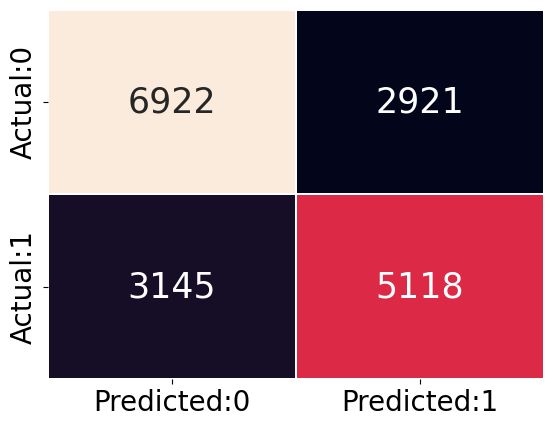

In [140]:
cm = confusion_matrix(ytest_dt, ypred_dt)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [141]:
print(classification_report(ytest_dt, ypred_dt))

              precision    recall  f1-score   support

           0       0.69      0.70      0.70      9843
           1       0.64      0.62      0.63      8263

    accuracy                           0.66     18106
   macro avg       0.66      0.66      0.66     18106
weighted avg       0.66      0.66      0.66     18106



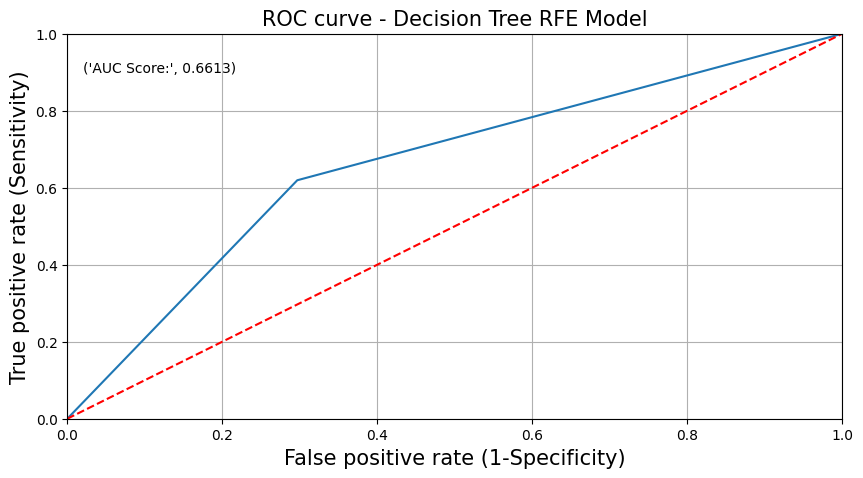

In [142]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_dt, ypred_proba_dt)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - Decision Tree RFE Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_dt, ypred_proba_dt),4)))
plt.grid(True)

In [143]:
RFE_model_evaluation.loc['DecisionTree'] = [accuracy_score(ytest_dt, ypred_dt), accuracy_score(ytrain_dt, ypred_dt_train),
                                          precision_score(ytest_dt, ypred_dt), precision_score(ytrain_dt, ypred_dt_train),
                                          recall_score(ytest_dt, ypred_dt), recall_score(ytrain_dt, ypred_dt_train),
                                          cohen_kappa_score(ytest_dt, ypred_dt), cohen_kappa_score(ytrain_dt, ypred_dt_train),
                                          f1_score(ytest_dt, ypred_dt), roc_auc_score(ytest_dt, ypred_proba_dt)]
RFE_model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
XGBoost RFE,0.761681,0.811977,0.728631,0.779617,0.761346,0.8161,0.521430,0.622179,0.744629,0.761654
RandomForest Classifier,0.738319,1.000000,0.722285,1.000000,0.693090,1.0000,0.470905,1.000000,0.707386,0.734689
DecisionTree,0.664973,1.000000,0.636646,1.000000,0.619388,1.0000,0.323332,1.000000,0.627898,0.661314


<a id="rfelogistic"></a>
## 17.4. Logistic Regression - RFE

In [144]:
X_train_rfe = X_train.iloc[:,1:]
X_test_rfe = X_test.iloc[:,1:]
logreg =  LogisticRegression()
logreg_model = RFE(estimator = logreg, n_features_to_select = 10)
rfe_model = logreg_model.fit(X_train_rfe, y_train)
feat_index = pd.Series(data = rfe_model.ranking_, index = X_train_rfe.columns)
signi_feat_rfe_log = feat_index[feat_index==1].index
print(signi_feat_rfe_log)

Index(['purchased_approved', 'delivered_estimated', 'purchased_delivered',
       'freight_value', 'product_length_cm', 'payment_installments',
       'customer_state_northern', 'payment_type_credit_card',
       'payment_type_debit_card', 'payment_type_voucher'],
      dtype='object')


In [145]:
xtrain_log, xtest_log, ytrain_log, ytest_log = train_test_split(X[signi_feat_rfe_log], df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_log.shape)
print('ytrain: ', ytrain_log.shape)
print('xtest: ', xtest_log.shape)
print('ytest: ', ytest_log.shape)

xtrain:  (72422, 10)
ytrain:  (72422,)
xtest:  (18106, 10)
ytest:  (18106,)


In [146]:
tstats,pvals = stats.ttest_ind(xtrain_log, xtest_log)
ref_df = pd.DataFrame(pvals,index=xtrain_log.columns,columns=['pvals'])
(ref_df < 0.05).any()

pvals    False
dtype: bool

In [147]:
logreg = LogisticRegression()
logreg = logreg.fit(xtrain_log, ytrain_log)

In [148]:
ypred_proba_log = logreg.predict(xtest_log)
ypred_log = [0 if i < 0.5 else 1 for i in ypred_proba_log]
ypred_log[:10]

[0, 0, 0, 1, 0, 0, 1, 0, 1, 1]

In [149]:
ypred_proba_log_train = logreg.predict(xtrain_log)
ypred_log_train = [0 if i < 0.5 else 1 for i in ypred_proba_log_train]

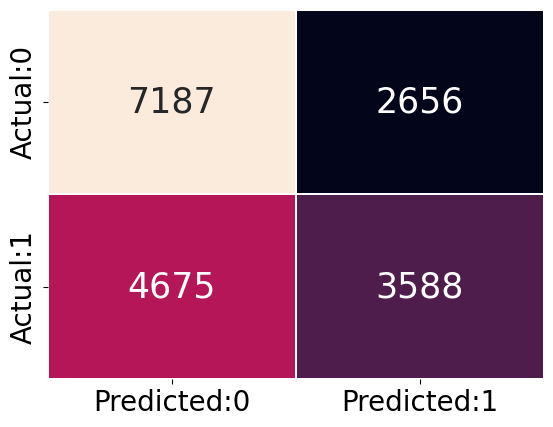

In [150]:
cm = confusion_matrix(ytest_log, ypred_log)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [151]:
print(classification_report(ytest_log, ypred_log))

              precision    recall  f1-score   support

           0       0.61      0.73      0.66      9843
           1       0.57      0.43      0.49      8263

    accuracy                           0.60     18106
   macro avg       0.59      0.58      0.58     18106
weighted avg       0.59      0.60      0.59     18106



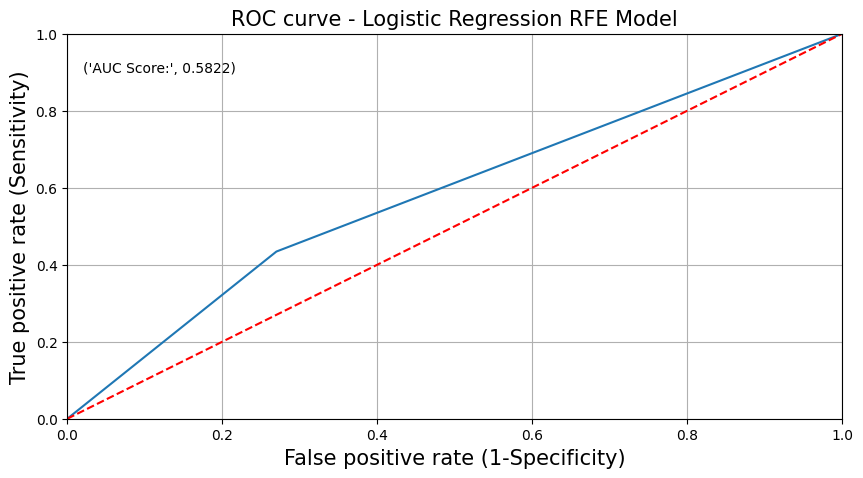

In [152]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_log, ypred_proba_log)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - Logistic Regression RFE Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_log, ypred_proba_log),4)))
plt.grid(True)

In [153]:
RFE_model_evaluation.loc['Logistic Regression'] = [accuracy_score(ytest_log, ypred_log), accuracy_score(ytrain_log, ypred_log_train),
                                          precision_score(ytest_log, ypred_log), precision_score(ytrain_log, ypred_log_train),
                                          recall_score(ytest_log, ypred_log), recall_score(ytrain_log, ypred_log_train),
                                          cohen_kappa_score(ytest_log, ypred_log), cohen_kappa_score(ytrain_log, ypred_log_train),
                                          f1_score(ytest_log, ypred_log), roc_auc_score(ytest_log, ypred_proba_log)]
RFE_model_evaluation

,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_kappa,train_kappa,f1_score,roc_auc_score
XGBoost RFE,0.761681,0.811977,0.728631,0.779617,0.761346,0.81610,0.521430,0.622179,0.744629,0.761654
RandomForest Classifier,0.738319,1.000000,0.722285,1.000000,0.693090,1.00000,0.470905,1.000000,0.707386,0.734689
DecisionTree,0.664973,1.000000,0.636646,1.000000,0.619388,1.00000,0.323332,1.000000,0.627898,0.661314
Logistic Regression,0.595107,0.603076,0.574632,0.583503,0.434225,0.43594,0.167677,0.181623,0.494658,0.582194


In [154]:
RFE_model_evaluation[['test_recall']].sort_values('test_recall', ascending = False)

,test_recall
XGBoost RFE,0.761346
RandomForest Classifier,0.693090
DecisionTree,0.619388
Logistic Regression,0.434225


**Observations:**
1. Looking at the **test recall scores**, we conclude that the **2 best performing models** as **XGBoost** and **Random Forest Classifier**. 
2. So we tune those two models to get the hyperparameters and thereafter the best model. 

<a id="grid"></a>
# 18. Hyperparameter Tuning

<a id="gridrf"></a>
## 18.1. Tuned Random Forest Classifier

In [155]:
xtrain_random, xtest_random, ytrain_random, ytest_random = train_test_split(X[signi_feat_rfe_rf], df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_random.shape)
print('ytrain: ', ytrain_random.shape)
print('xtest: ', xtest_random.shape)
print('ytest: ', ytest_random.shape)

xtrain:  (72422, 10)
ytrain:  (72422,)
xtest:  (18106, 10)
ytest:  (18106,)


In [156]:
rand = RandomForestClassifier(random_state = 10)
parameters = [{'criterion': ['gini', 'entropy'],
               'max_features': ['sqrt', 'log2'],
               'max_depth': range(2, 7),
               'min_samples_split' : range(2, 7),
               'max_leaf_nodes': range(2, 10)}]
gcv_rf = GridSearchCV(estimator = rand, param_grid = parameters, cv = 5)
gcv_rf.fit(xtrain_random, ytrain_random)

KeyboardInterrupt: 

In [ ]:
gcv_rf.best_params_

In [ ]:
rand = RandomForestClassifier(criterion = 'entropy',max_depth = 6, max_features = 'sqrt', max_leaf_nodes = 9, min_samples_split = 2)
rand_model = rand.fit(xtrain_random,ytrain_random)

In [ ]:
ypred_proba_random = rand_model.predict(xtest_random)
ypred_random = [0 if i < 0.5 else 1 for i in ypred_proba_random]
ypred_random[:10]

In [ ]:
ypred_proba_random_train = rand_model.predict(xtrain_random)
ypred_random_train = [0 if i < 0.5 else 1 for i in ypred_proba_random_train]

In [ ]:
cm = confusion_matrix(ytest_random, ypred_random)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [ ]:
print(classification_report(ytest_random, ypred_random))

In [ ]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_random, ypred_proba_random)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - Hyperparameter tuned Random Forest Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_random, ypred_proba_random),4)))
plt.grid(True)

In [ ]:
cols = ['test_accuracy', 'train_accuracy', 'test_precision', 'train_precision','test_recall','train_recall', 'test_kappa', 'train_kappa', 'f1_score','roc_auc_score']
model_evaluation_tuned = pd.DataFrame(columns=cols)
model_evaluation_tuned.loc['Tuned RandomForest Classifier'] = [accuracy_score(ytest_random, ypred_random), accuracy_score(ytrain_random, ypred_random_train),
                                          precision_score(ytest_random, ypred_random), precision_score(ytrain_random, ypred_random_train),
                                          recall_score(ytest_random, ypred_random), recall_score(ytrain_random, ypred_random_train),
                                          cohen_kappa_score(ytest_random, ypred_random), cohen_kappa_score(ytrain_random, ypred_random_train),
                                          f1_score(ytest_random, ypred_random), roc_auc_score(ytest_random, ypred_proba_random)]
model_evaluation_tuned

<a id="gridxgb"></a>
## 18.2. Tuned XGBoost Classifier

In [ ]:
xtrain_xg, xtest_xg, ytrain_xg, ytest_xg = train_test_split(X[signi_feat_rfe_xg], df_target, test_size = 0.2, random_state = 500)
print('xtrain: ', xtrain_xg.shape)
print('ytrain: ', ytrain_xg.shape)
print('xtest: ', xtest_xg.shape)
print('ytest: ', ytest_xg.shape)

In [ ]:
xgb = XGBClassifier(random_state = 10)
parameters = [{'n_estimators': [30, 40, 50, 70, 90],
               'max_depth': range(2, 7),
                'learning_rate': [0.1, 0.2, 0.4, 0.5]}]
gcv_xgb = GridSearchCV(estimator = xgb, param_grid = parameters, cv = 5)
gcv_xgb.fit(xtrain_xg, ytrain_xg)
gcv_xgb.best_params_

In [ ]:
xgBoost = XGBClassifier(learning_rate = 0.5,max_depth = 6,n_estimators = 90)
xgBoost.fit(xtrain_xg, ytrain_xg)

In [ ]:
ypred_proba_xg = xgBoost.predict(xtest_xg)
ypred_xg = [0 if i < 0.5 else 1 for i in ypred_proba_xg]
ypred_xg[:10]

In [ ]:
ypred_proba_xg_train = xgBoost.predict(xtrain_xg)
ypred_xg_train = [0 if i < 0.5 else 1 for i in ypred_proba_xg_train]

In [ ]:
cm = confusion_matrix(ytest_xg, ypred_xg)
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1'], index = ['Actual:0','Actual:1'])
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cbar = False, 
            linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [ ]:
print(classification_report(ytest_xg, ypred_xg))

In [ ]:
plt.figure(figsize = (10, 5))
fpr, tpr, thresholds = roc_curve(ytest_xg, ypred_proba_xg)
plt.plot(fpr, tpr)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.plot([0, 1], [0, 1],'r--')
plt.title('ROC curve - Hyperparameter tuned XGBoost Model', fontsize = 15)
plt.xlabel('False positive rate (1-Specificity)', fontsize = 15)
plt.ylabel('True positive rate (Sensitivity)', fontsize = 15)
plt.text(x = 0.02, y = 0.9, s = ('AUC Score:', round(metrics.roc_auc_score(ytest_xg, ypred_proba_xg),4)))
plt.grid(True)

In [ ]:
plt.figure(figsize=(10, 5))
important_features = pd.DataFrame({'Features': xtrain_xg.columns, 
                                   'Importance': xgBoost.feature_importances_})
important_features = important_features.sort_values('Importance', ascending = False)
sns.barplot(x = 'Importance', y = 'Features', data = important_features)
plt.title('Feature Importance',color='black',fontsize=20,fontweight='bold')
plt.xlabel('Importance',color='black',fontsize=15)
plt.ylabel('Features',color='black',fontsize=15)
plt.show()

In [ ]:
# ── Save the best model (Tuned XGBoost) for use in Streamlit / production ──
import joblib, os

model_payload = {
    "model":    xgBoost,
    "features": list(xtrain_xg.columns),
}

save_path = os.path.join(os.path.dirname(os.getcwd()), "deployment", "tuned_xgboost_model.pkl")
joblib.dump(model_payload, save_path)
print(f"Model saved to: {save_path}")
print(f"Features ({len(model_payload['features'])}):", model_payload['features'])


In [ ]:
model_evaluation_tuned.loc['Tuned XGBoost Classifier'] = [accuracy_score(ytest_xg, ypred_xg), accuracy_score(ytrain_xg, ypred_xg_train),
                                          precision_score(ytest_xg, ypred_xg), precision_score(ytrain_xg, ypred_xg_train),
                                          recall_score(ytest_xg, ypred_xg), recall_score(ytrain_xg, ypred_xg_train),
                                          cohen_kappa_score(ytest_xg, ypred_xg), cohen_kappa_score(ytrain_xg, ypred_xg_train),
                                          f1_score(ytest_xg, ypred_xg), roc_auc_score(ytest_xg, ypred_proba_xg)]
model_evaluation_tuned

<a id="interpretation"></a>
# 19. Model Interpretation

Since the **target class is balanced**, we can **any of the metrics** below to measure the **model performance**. 

1. **Accuracy**: This metric measures the **proportion of correct predictions** made by the model over all predictions made. It is a simple and intuitive measure, but it may not be the best choice when classes are imbalanced.
2. **Precision**: Precision measures the **proportion of true positives (correctly predicted positives) out of all predicted positives**. It is a useful metric when you want to minimize false positives.
3. **Recall**: Recall measures the **proportion of true positives out of all actual positives in the data**. It is a useful metric when you want to minimize false negatives.
4. **F1 score**: The F1 score is the **harmonic mean of precision and recall**. It balances the tradeoff between precision and recall and provides a single measure of performance.
5. **Area under the ROC curve (AUC-ROC)**: AUC-ROC is a metric that measures the **ability of the model to distinguish between positive and negative classes**. It is a good metric when you want to evaluate the overall performance of the model across different thresholds.

The choice of metric depends on the specific goals of the problem and the tradeoffs we want to make between different types of errors.

**Classification report (XG Boost Model)**
1. Percision = 0.77 (high - Number of False positives are low)
2. Recall = 0.77 (high - Number of False negatives are low)
3. F1 Score = 0.77 (high - imbalance in recall and percision is low)
4. Accuracy = 0.77

**The XG Boost is the best model for predicting Churn classification**.

## Pipeline